In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# predictions = pd.read_csv('../results/test_predictions.csv')
# metrics = pd.read_csv('../results/test_metrics.csv')


predictions = pd.read_csv('/Users/sr/Documents/code/forecasting-at-scale/results/test_xgboost_predictions.csv')
metrics = pd.read_csv('/Users/sr/Documents/code/forecasting-at-scale/results/test_xgboost_metrics.csv')

print(f'Predictions: {predictions.shape}')
print(f'Metrics: {metrics.shape}')
predictions.head()

Predictions: (852, 6)
Metrics: (30, 5)


,store_idx,date,prediction,actual,store_id,product
0,0,2024-11-11,44.911606,52.0,1,7897395060107
1,0,2024-11-12,33.525471,70.0,1,7897395060107
2,0,2024-11-13,26.477093,129.0,1,7897395060107
3,0,2024-11-14,32.355846,242.0,1,7897395060107
4,0,2024-11-15,59.564857,419.0,1,7897395060107


In [2]:
# Overall metrics summary
print('=== Overall ===')
print(f"Avg RMSE:  {metrics['rmse'].mean():.2f}")
print(f"Median RMSE: {metrics['rmse'].median():.2f}")
print(f"Avg MAE:   {metrics['mae'].mean():.2f}")
print(f"Avg MAPE:  {metrics['mape'].mean():.1f}%")
print()
metrics.describe()

=== Overall ===
Avg RMSE:  2309.72
Median RMSE: 147.42
Avg MAE:   901.98
Avg MAPE:  147.0%



,store_idx,rmse,mae,mape,store_id
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,14.500000,2309.723868,901.981947,146.976976,15.500000
std,8.803408,6348.878763,2385.907104,244.035023,8.803408
min,0.000000,46.239344,34.625395,42.514573,1.000000
25%,7.250000,96.419089,58.228832,58.890090,8.250000
50%,14.500000,147.423603,83.927105,67.528648,15.500000
75%,21.750000,263.335898,121.250896,90.507997,22.750000
max,29.000000,23876.715094,8621.486117,1110.563902,30.000000


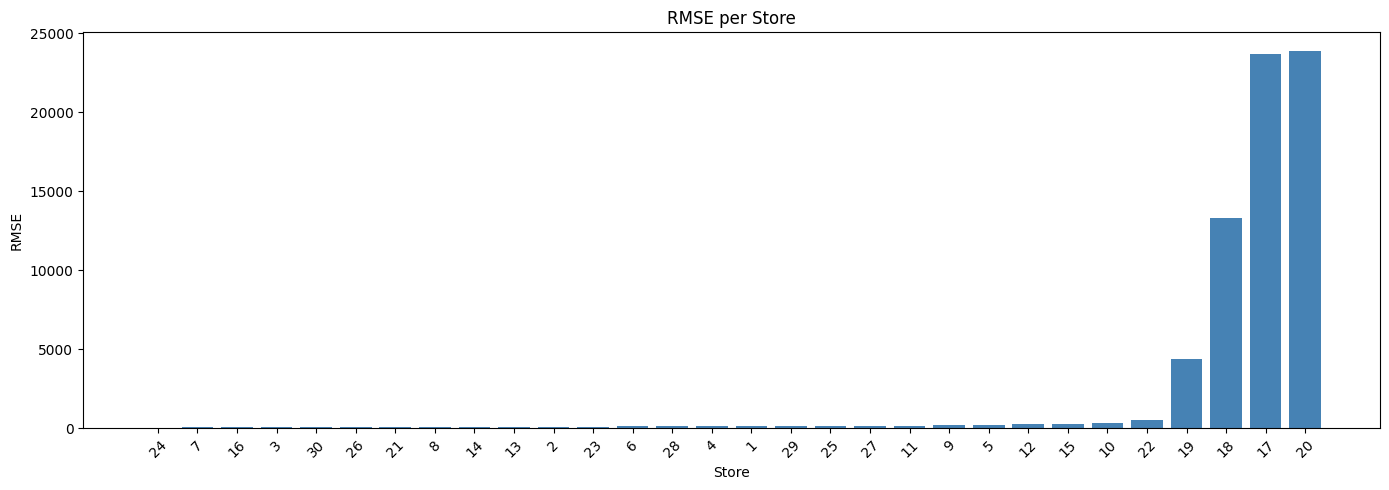

In [3]:
# RMSE per store
fig, ax = plt.subplots(figsize=(14, 5))
metrics_sorted = metrics.sort_values('rmse')
ax.bar(metrics_sorted['store_id'].astype(str), metrics_sorted['rmse'], color='steelblue')
ax.set_xlabel('Store')
ax.set_ylabel('RMSE')
ax.set_title('RMSE per Store')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

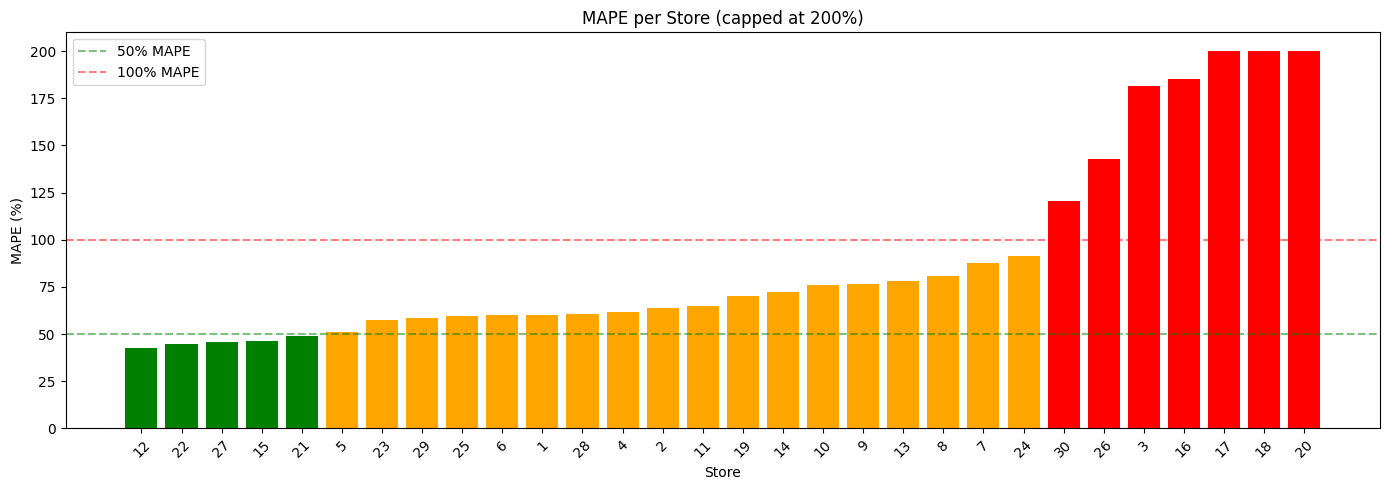

In [4]:
# MAPE per store (capped at 200% for readability)
fig, ax = plt.subplots(figsize=(14, 5))
metrics_sorted = metrics.sort_values('mape')
colors = ['green' if m < 50 else 'orange' if m < 100 else 'red' for m in metrics_sorted['mape']]
ax.bar(metrics_sorted['store_id'].astype(str), metrics_sorted['mape'].clip(upper=200), color=colors)
ax.axhline(y=50, color='green', linestyle='--', alpha=0.5, label='50% MAPE')
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% MAPE')
ax.set_xlabel('Store')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE per Store (capped at 200%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

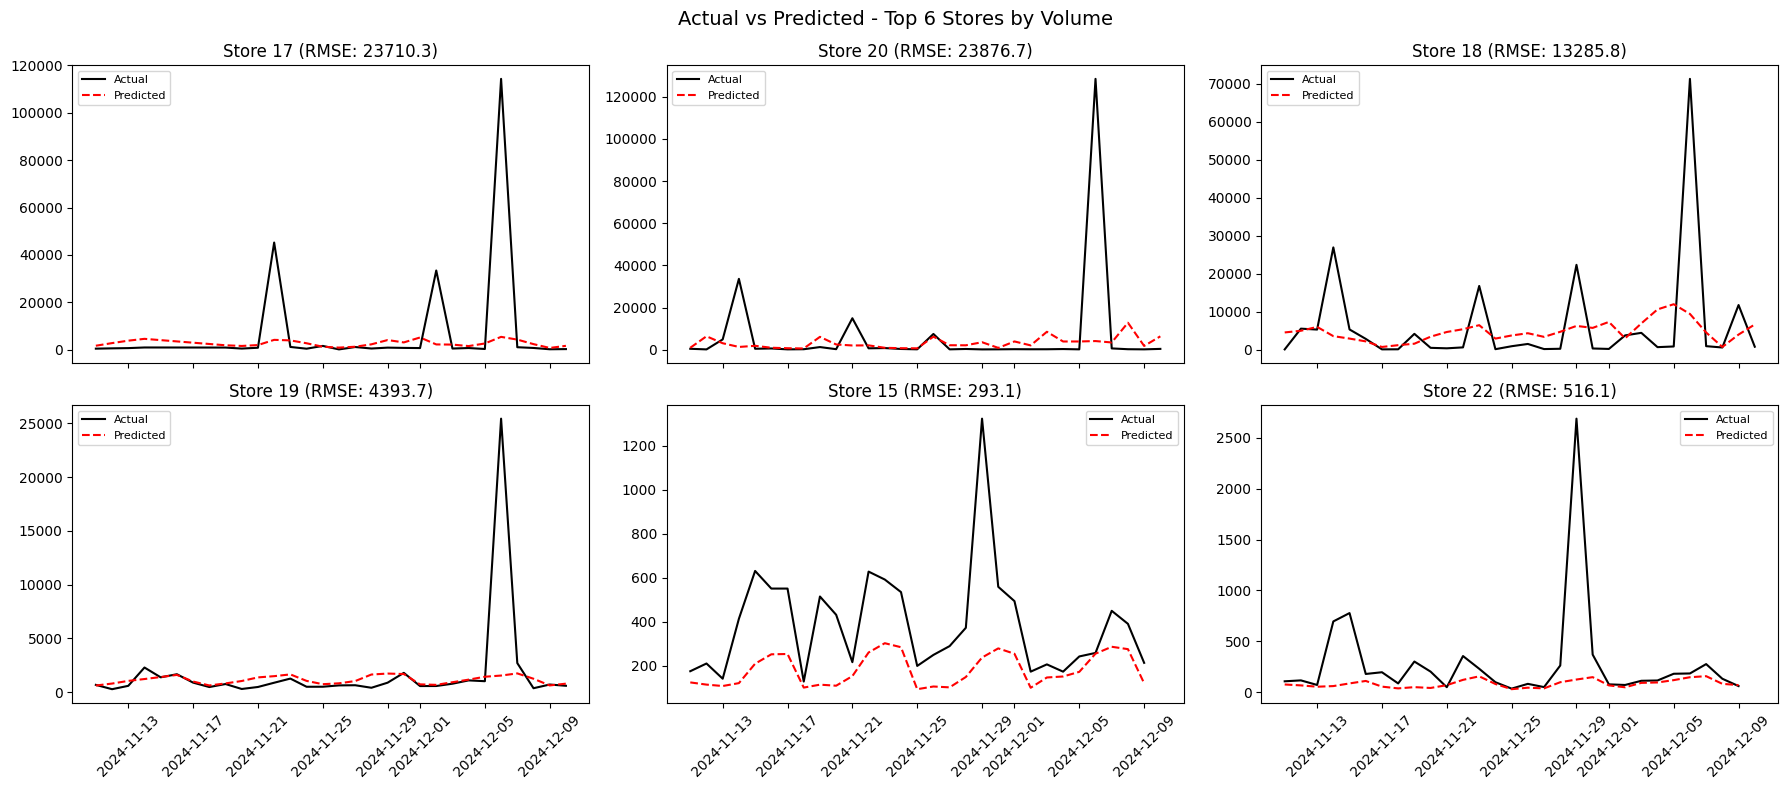

In [5]:
# Actual vs Predicted for top 6 stores by volume
predictions['date'] = pd.to_datetime(predictions['date'])
top_stores = predictions.groupby('store_id')['actual'].sum().nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for ax, store in zip(axes.flatten(), top_stores):
    store_data = predictions[predictions['store_id'] == store].sort_values('date')
    ax.plot(store_data['date'], store_data['actual'], label='Actual', color='black', linewidth=1.5)
    ax.plot(store_data['date'], store_data['prediction'], label='Predicted', color='red', linewidth=1.5, linestyle='--')
    store_rmse = metrics[metrics['store_id'] == store]['rmse'].values[0]
    ax.set_title(f'Store {store} (RMSE: {store_rmse:.1f})')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Actual vs Predicted - Top 6 Stores by Volume', fontsize=14)
plt.tight_layout()
plt.show()

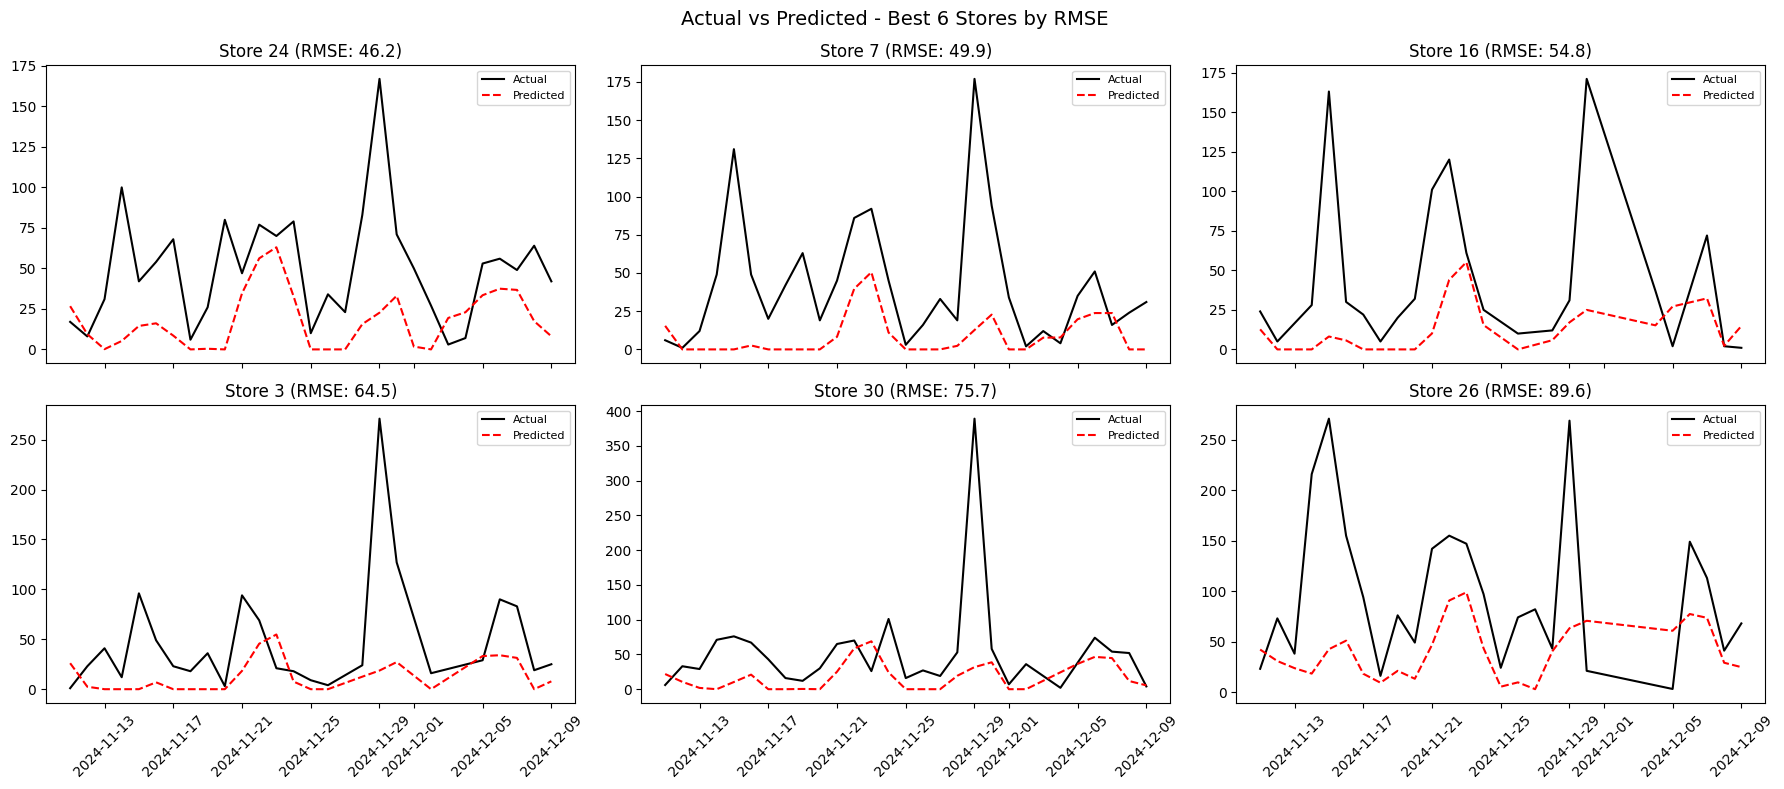

In [6]:
# Actual vs Predicted for best 6 stores by RMSE
best_stores = metrics.nsmallest(6, 'rmse')['store_id'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for ax, store in zip(axes.flatten(), best_stores):
    store_data = predictions[predictions['store_id'] == store].sort_values('date')
    ax.plot(store_data['date'], store_data['actual'], label='Actual', color='black', linewidth=1.5)
    ax.plot(store_data['date'], store_data['prediction'], label='Predicted', color='red', linewidth=1.5, linestyle='--')
    store_rmse = metrics[metrics['store_id'] == store]['rmse'].values[0]
    ax.set_title(f'Store {store} (RMSE: {store_rmse:.1f})')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Actual vs Predicted - Best 6 Stores by RMSE', fontsize=14)
plt.tight_layout()
plt.show()

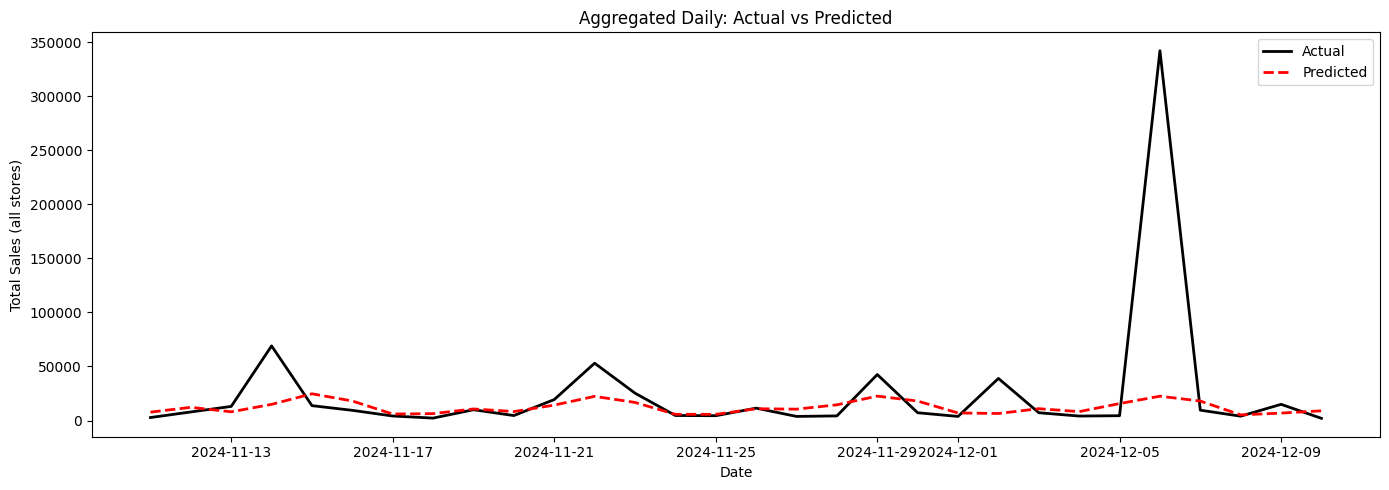

In [7]:
# Aggregated: total actual vs total predicted per day
daily = predictions.groupby('date')[['actual', 'prediction']].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['actual'], label='Actual', color='black', linewidth=2)
ax.plot(daily['date'], daily['prediction'], label='Predicted', color='red', linewidth=2, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (all stores)')
ax.set_title('Aggregated Daily: Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.show()

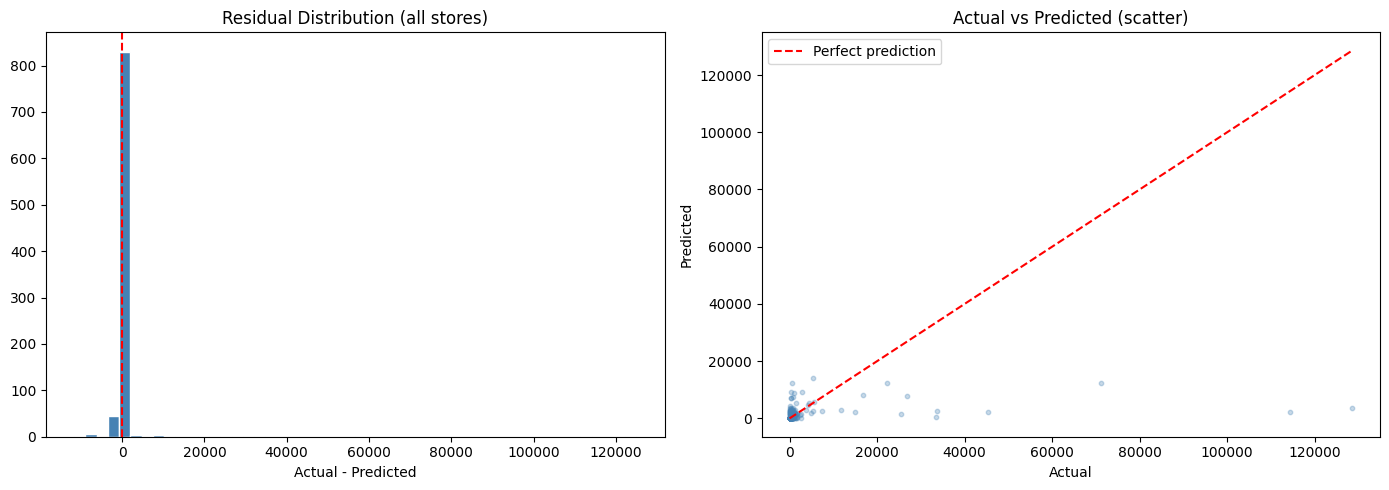

In [8]:
# Residual distribution
predictions['residual'] = predictions['actual'] - predictions['prediction']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(predictions['residual'], bins=50, color='steelblue', edgecolor='white')
ax1.axvline(x=0, color='red', linestyle='--')
ax1.set_title('Residual Distribution (all stores)')
ax1.set_xlabel('Actual - Predicted')

ax2.scatter(predictions['actual'], predictions['prediction'], alpha=0.3, s=10, color='steelblue')
max_val = max(predictions['actual'].max(), predictions['prediction'].max())
ax2.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title('Actual vs Predicted (scatter)')
ax2.legend()

plt.tight_layout()
plt.show()